# Business Understanding

## Project Domain

Proyek ini bergerak di bidang Kesehatan (HealthTech), khususnya pada prediksi penyakit kanker paru-paru menggunakan teknik Machine Learning. Dengan memanfaatkan data survei gejala dan gaya hidup, sistem ini membantu memprediksi risiko kanker paru-paru lebih dini, sehingga dapat mendukung proses deteksi awal dan pengambilan keputusan medis.

## Problem Statements

Kanker paru-paru merupakan salah satu penyebab utama kematian di seluruh dunia karena sering kali terlambat terdeteksi. Proses diagnosis yang manual memakan waktu dan bergantung pada pemeriksaan lanjutan seperti CT Scan atau biopsi. Banyak pasien tidak menyadari gejala awal yang mereka alami, sehingga risiko kanker baru diketahui saat sudah memasuki stadium lanjut.

## Goals

Tujuan dari proyek ini adalah:

Mengembangkan model machine learning yang mampu memprediksi risiko kanker paru-paru berdasarkan input gejala dan gaya hidup pasien.

Mencapai akurasi minimal 80% dalam prediksi untuk memastikan keandalan sistem.

Menyediakan aplikasi berbasis Streamlit yang dapat digunakan oleh masyarakat umum maupun tenaga medis untuk mendeteksi risiko secara praktis dan cepat.

Mempermudah proses skrining awal sehingga pasien berisiko bisa segera diarahkan untuk pemeriksaan lanjutan.

## Solution Statements

Solusi yang ditawarkan dalam proyek ini meliputi:

Menggunakan Artificial Neural Network (ANN) untuk membangun model klasifikasi risiko kanker paru-paru.

Melakukan preprocessing terhadap data survei gejala, mengatasi missing value, encoding variabel, dan scaling.

Menggunakan framework TensorFlow Lite (TFLite) untuk mendukung deployment model yang ringan.

Membangun aplikasi Streamlit yang mudah digunakan, di mana pengguna cukup mengisi form mengenai gejala dan gaya hidup, lalu mendapatkan hasil prediksi risiko.

Seluruh pipeline model disimpan dalam format .tflite, serta scaler dan label encoder disimpan dalam file .pkl, memudahkan proses deployment di platform cloud maupun aplikasi mobile/web.

# Data Understanding

## Import data dari kaggle

In [70]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"abdullahhanif123","key":"1017140fd6c8650a0eedf1f2ffb0a5d4"}'}

In [71]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [72]:
!kaggle datasets download -d nancyalaswad90/lung-cancer

Dataset URL: https://www.kaggle.com/datasets/nancyalaswad90/lung-cancer
License(s): CC-BY-NC-SA-4.0
lung-cancer.zip: Skipping, found more recently modified local copy (use --force to force download)


In [73]:
!mkdir lung-cancer
!unzip lung-cancer.zip -d lung-cancer
!ls lung-cancer

mkdir: cannot create directory ‘lung-cancer’: File exists
Archive:  lung-cancer.zip
replace lung-cancer/survey lung cancer.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 'survey lung cancer.csv'


## Import Library yang dibutuhkan

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [75]:
data = pd.read_csv('lung-cancer/survey lung cancer.csv')

In [76]:
  data.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


# Exploratory Data Analysis

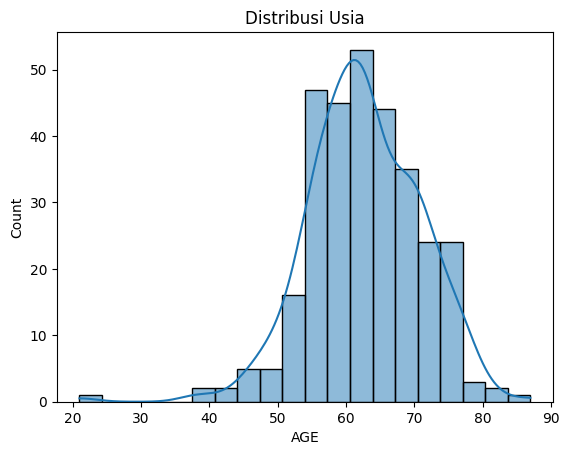

In [8]:
sns.histplot(data['AGE'], bins=20, kde=True)
plt.title('Distribusi Usia')
plt.show()

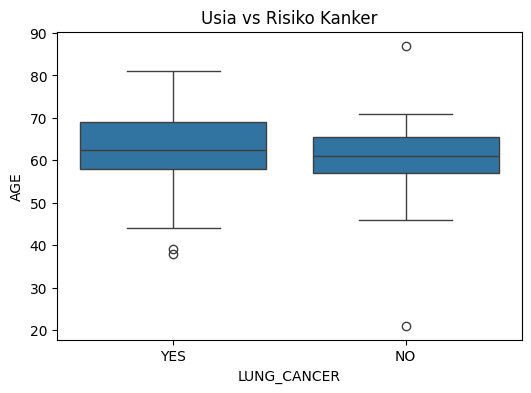

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(x='LUNG_CANCER', y='AGE', data=data)
plt.title('Usia vs Risiko Kanker')
plt.show()

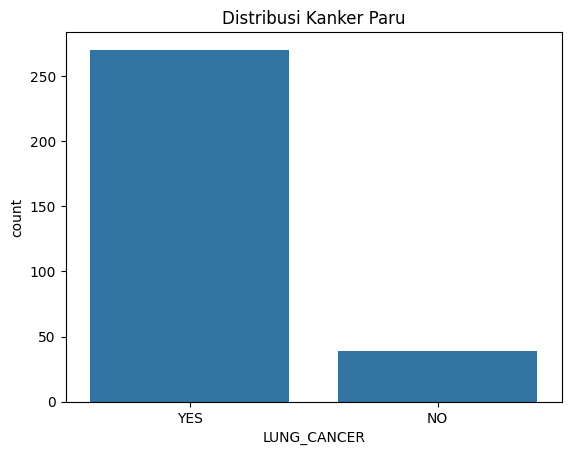

In [10]:
sns.countplot(x='LUNG_CANCER', data=data)
plt.title('Distribusi Kanker Paru')
plt.show()

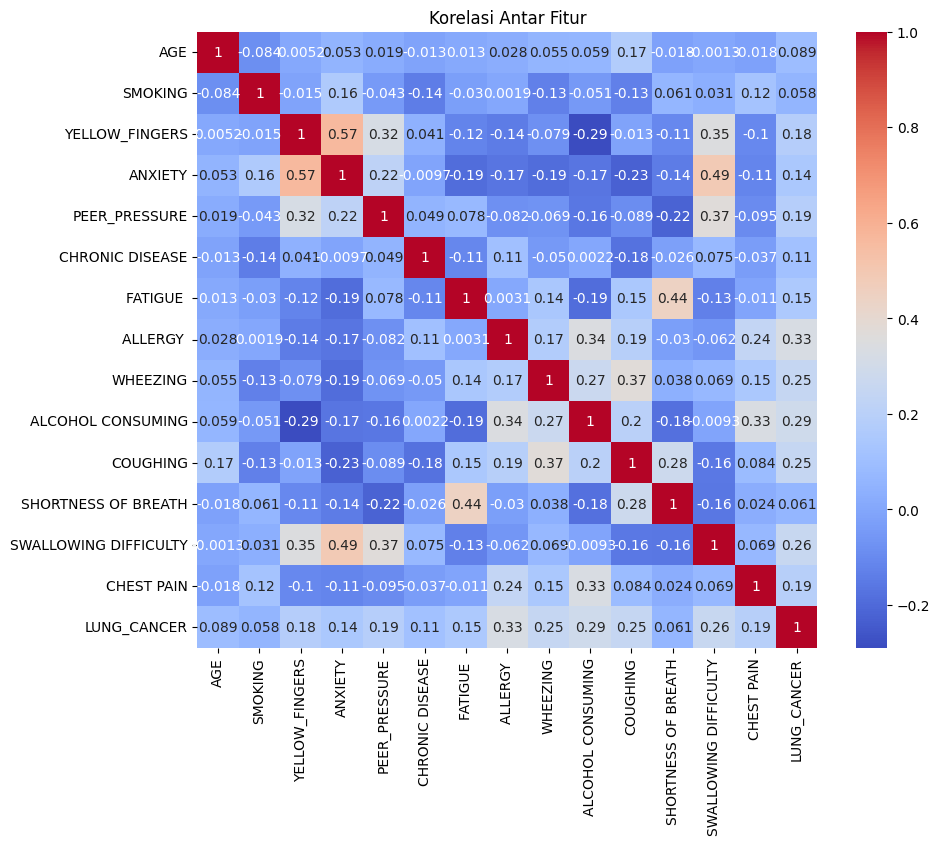

In [23]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Korelasi Antar Fitur')
plt.show()

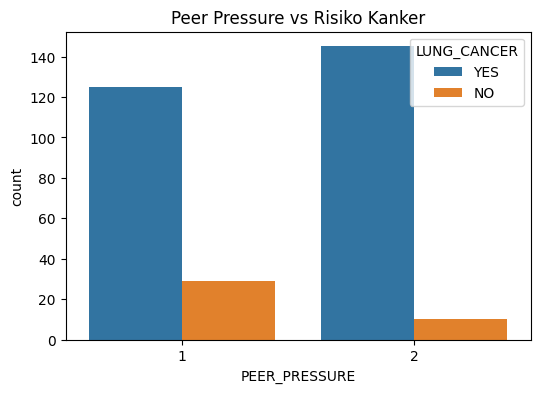

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='PEER_PRESSURE', hue='LUNG_CANCER', data=data)
plt.title('Peer Pressure vs Risiko Kanker')
plt.show()


# Data Preparation

In [27]:
data.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,1
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,1
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,0
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,0
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,0


In [14]:
le = LabelEncoder()
data['LUNG_CANCER'] = le.fit_transform(data['LUNG_CANCER'])

In [15]:
print(data.isnull().sum())

GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64


In [31]:
data['GENDER'] = le.fit_transform(data['GENDER'])

In [32]:
X = data.drop(columns=['LUNG_CANCER'])
y = data['LUNG_CANCER']

In [33]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Modeling

In [54]:
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [55]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [56]:
history = model.fit(X_train, y_train, epochs=30, validation_data=(X_test, y_test), batch_size=16)

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.4958 - loss: 0.6991 - val_accuracy: 0.9839 - val_loss: 0.3674
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8713 - loss: 0.3634 - val_accuracy: 0.9677 - val_loss: 0.1845
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8374 - loss: 0.3209 - val_accuracy: 0.9677 - val_loss: 0.1428
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8482 - loss: 0.2681 - val_accuracy: 0.9677 - val_loss: 0.1295
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9172 - loss: 0.2145 - val_accuracy: 0.9516 - val_loss: 0.1211
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9107 - loss: 0.2067 - val_accuracy: 0.9516 - val_loss: 0.1163
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9488 - loss: 0.1805 - val_accuracy: 0.9516 - val_loss: 0.1168
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9385 - loss: 0.1655 - val_accuracy: 0.9516 - val_loss

# Evaluation

In [57]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Akurasi: {accuracy*100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9577 - loss: 0.1239
Akurasi: 96.77%


In [58]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


In [59]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.98      0.98      0.98        60

    accuracy                           0.97        62
   macro avg       0.74      0.74      0.74        62
weighted avg       0.97      0.97      0.97        62



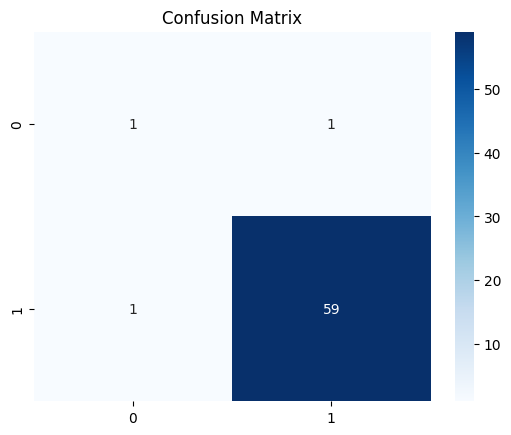

In [60]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Deployment

## Model Simulation

In [61]:
data.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,1,69,1,2,2,1,1,2,1,2,2,2,2,2,2,1
1,1,74,2,1,1,1,2,2,2,1,1,1,2,2,2,1
2,0,59,1,1,1,2,1,2,1,2,1,2,2,1,2,0
3,1,63,2,2,2,1,1,1,1,1,2,1,1,2,2,0
4,0,63,1,2,1,1,1,1,1,2,1,2,2,1,1,0


In [62]:
features = ['GENDER','AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY',
            'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ',
            'WHEEZING', 'ALCOHOL CONSUMING', 'COUGHING',
            'SHORTNESS OF BREATH', 'SWALLOWING DIFFICULTY', 'CHEST PAIN']

In [63]:
sample_input = np.array([[1, 55, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1]])

In [64]:
sample_input_df = pd.DataFrame(sample_input, columns=features)

In [65]:
sample_input_scaled = scaler.transform(sample_input_df)

In [66]:
predicted_prob = model.predict(sample_input_scaled)
predicted_class = (predicted_prob > 0.5).astype(int)[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


In [67]:
hasil_prediksi = 'Risiko Kanker Paru-paru' if predicted_class == 1 else 'Tidak Berisiko'
print(f"Hasil Prediksi: {hasil_prediksi}")

Hasil Prediksi: Tidak Berisiko


## Save Model

In [68]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model
with open('lung_cancer.tflite', 'wb') as f:
    f.write(tflite_model)


Saved artifact at '/tmp/tmpjl10al1m'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 15), dtype=tf.float32, name='keras_tensor_11')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134910856175568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134910856174416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134910830305232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134910830301200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134910830301584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134910830302160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134910830303504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134910830301968: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [69]:
import joblib
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']